In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

In [3]:
df = pd.read_csv("../src/all_patterns_combined.csv")
print (f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2765, 6)


,title,description,final_description,skill_level,pattern_link,local_path
0,Quick n' Cozy Crochet Afghan,The Quick n' Cozy Crochet Afghan is the ultima...,Quick n' Cozy Crochet Afghan The Quick n' Cozy...,Beginner,https://www.allfreecrochet.com/Crochet-Afghan-...,Quick_n_Cozy_Crochet_Afghan.jpg
1,World's Easiest Afghan,If you've been searching for easy afghan patte...,World's Easiest Afghan If you've been searchin...,Beginner,https://www.allfreecrochet.com/Crochet-Afghan-...,Worlds_Easiest_Afghan.jpg
2,Ribbed Fingerless Gloves,"""These crochet ribbed fingerless gloves are ma...","Ribbed Fingerless Gloves ""These crochet ribbed...",Beginner,https://www.allfreecrochet.com/Gloves-and-Mitt...,Ribbed_Fingerless_Gloves.jpg
3,Chunky Adult Slippers,Learn how to crochet an adorable pair of Chunk...,Chunky Adult Slippers Learn how to crochet an ...,Beginner,https://www.allfreecrochet.com/Socks-and-Slipp...,Chunky_Adult_Slippers.jpg
4,Quick Little Bag,"""This Quick Little Bag is just that, and it ca...","Quick Little Bag ""This Quick Little Bag is jus...",Beginner,https://www.allfreecrochet.com/Crochet-Bag-Pat...,Quick_Little_Bag.jpg


In [ ]:
docs = (df['title'].fillna('') + " " + df['final_description'].fillna('')).tolist()
vectorizer = TfidfVectorizer(stop_words="english", sublinear_tf=True, min_df=2)
tfidf_matrix = vectorizer.fit_transform(docs)

max_k = min(5000, tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1] - 1) 
svd_full = TruncatedSVD(n_components=max_k, random_state=4300)
svd_full.fit(tfidf_matrix)
cumvar = np.cumsum(svd_full.explained_variance_ratio_)
ks = np.arange(1, len(cumvar) + 1)

In [5]:
cumvar_df = pd.DataFrame({'k': ks, 'cumulative_variance': cumvar})
cumvar_df.head()

,k,cumulative_variance
0,1,0.014219
1,2,0.037216
2,3,0.053260
3,4,0.066779
4,5,0.077371


In [6]:
k_opt

np.int64(824)

50% variance explained at k=242
70% variance explained at k=562
80% variance explained at k=824
90% variance explained at k=1239


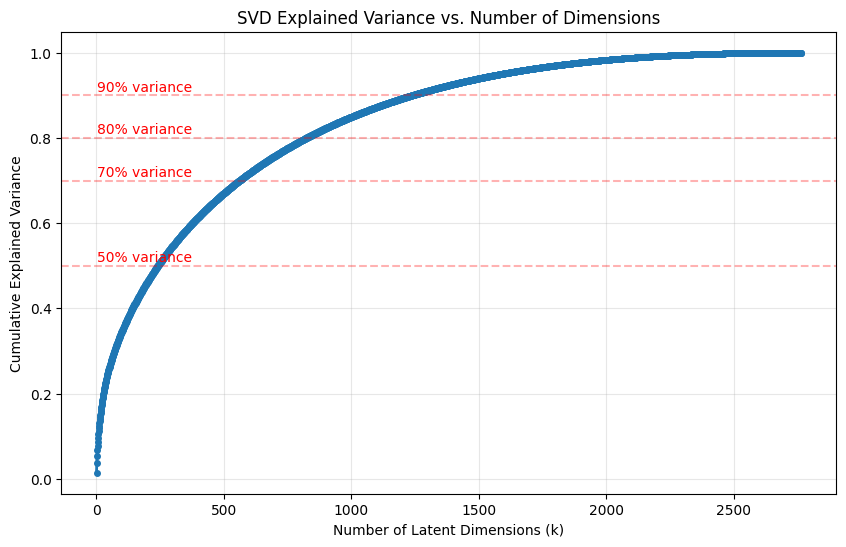

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(cumvar_df['k'], cumvar_df['cumulative_variance'], marker='o', linestyle='-', linewidth=2, markersize=4)
for threshold in [0.5, 0.7, 0.8, 0.9]: 
    k_at_thresh = np.searchsorted(cumvar, threshold) + 1 
    plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.3) 
    plt.text(1, threshold + 0.01, f'{int(threshold*100)}% variance', color='red', fontsize=10) 
    print(f"{int(threshold*100)}% variance explained at k={k_at_thresh}")

plt.xlabel("Number of Latent Dimensions (k)")
plt.ylabel("Cumulative Explained Variance")
plt.title("SVD Explained Variance vs. Number of Dimensions")
plt.grid(alpha=0.3)
plt.show()

In [21]:
k_opt = np.searchsorted(cumvar, 0.7) + 1
svd_reduced = TruncatedSVD(n_components=k_opt, random_state=4300)
docs_compressed = svd_reduced.fit_transform(tfidf_matrix)
words_compressed = svd_reduced.components_.T

docs_normed = normalize(docs_compressed)
words_normed = normalize(words_compressed)

td_matrix_np = tfidf_matrix.toarray()

In [22]:
td_matrix_np.shape, df.shape

((2765, 5149), (2765, 6))

In [29]:
word = 'bright'

word_to_index = vectorizer.vocabulary_
index_to_word = {i:t for t,i in word_to_index.items()}

# cosine similarity
def closest_words(word_in, words_representation_in, k = 10):
    if word_in not in word_to_index: return "Not in vocab."
    sims = words_representation_in.dot(words_representation_in[word_to_index[word_in],:])
    asort = np.argsort(-sims)[:k+1]
    return [(index_to_word[i],sims[i]) for i in asort[1:]]

print("Using SVD matrix:")
for w, sim in closest_words(word, words_normed):
  try:
    print("{}, {:.3f}".format(w, sim))
  except:
    print("word not found")
print()
print("Without using SVD: using term-doc matrix directly:")
for w, sim in closest_words(word, td_matrix_np):
  try:
    print("{}, {:.3f}".format(w, sim))
  except:
    print("word not found")
print()

Using SVD matrix:
cheery, 0.481
quilt, 0.312
camel, 0.303
joyful, 0.278
decreased, 0.272
57, 0.270
triangular, 0.259
77in, 0.244
bold, 0.234
pastels, 0.233

Without using SVD: using term-doc matrix directly:
cals, 0.707
charted, 0.660
baumann, 0.613
beret, 0.585
berroco, 0.583
cara, 0.580
champagne, 0.573
bottoms, 0.554
expect, 0.553
future, 0.551



In [24]:
def search_query(query_text, words_normed, k=5):
    query_tfidf = vectorizer.transform([query_text]).toarray()
    query_vec_svd = normalize(np.dot(query_tfidf, words_normed)).squeeze()
    svd_sims = docs_normed.dot(query_vec_svd)
    svd_indices = np.argsort(-svd_sims)[:k]
    
    query_vec_tfidf = normalize(query_tfidf).squeeze()
    tfidf_sims = td_matrix_np.dot(query_vec_tfidf)
    tfidf_indices = np.argsort(-tfidf_sims)[:k]
    
    print(f"SEARCH QUERY: '{query_text}'")
    
    print("Using SVD (Semantic/Concept Search):")
    for idx in svd_indices:
        title = df.iloc[idx, 0]
        score = svd_sims[idx]
        contribution = query_vec_svd * docs_normed[idx]
        top_dims = np.argsort(-contribution)[:2]
        
        print(f" {score:.3f} -> {title}")
        print(f" (Matched on Latent Concepts: {top_dims})")
        
    print("\nUsing TF-IDF (Direct Keyword Search):")
    for idx in tfidf_indices:
        title = df.iloc[idx, 0]
        score = tfidf_sims[idx]
        if score > 0:
            print(f"  {score:.3f} -> {title}")

user_query = "bright colored fruit looking bag" 
search_query(user_query, words_normed)

SEARCH QUERY: 'bright colored fruit looking bag'
Using SVD (Semantic/Concept Search):
 0.483 -> Fruit Coasters
 (Matched on Latent Concepts: [428 496])
 0.254 -> Mosaic Crochet Tote Bag
 (Matched on Latent Concepts: [30 28])
 0.229 -> Premier Dragon Fruit Ankle Socks Knit
 (Matched on Latent Concepts: [52 60])
 0.226 -> Crochet Orange Pattern Free,Crochet Mini Bag,Crochet Pattern Orange,Free Crochet Patterns
 (Matched on Latent Concepts: [35 26])
 0.214 -> Crochet Mood Blanket - October
 (Matched on Latent Concepts: [304 384])

Using TF-IDF (Direct Keyword Search):
  0.350 -> Fruit Coasters
  0.156 -> Premier Dragon Fruit Ankle Socks Knit
  0.155 -> Orbital Dishcloth
  0.152 -> Mosaic Crochet Tote Bag
  0.137 -> Bright Ripple Throw in Red Heart With Love Solids - LW3324


In [27]:
i = 26
print("Top words in dimension", i)
dimension_col = words_compressed[:,i].squeeze()
asort = np.argsort(-dimension_col)
print([index_to_word[i] for i in asort[:10]])

Top words in dimension 26
['dishcloth', 'square', 'granny', 'kitchen', 'knit', 'hat', 'dishcloths', 'cotton', 'bulky', 'soft']
